# Flights Univariate Time Series EDA

Usually, Time-series datasets have more external variables grouped with the target variable that varies with each instance. This provides more insights to the data itself and is used in some models to get a more complex algorithm to then predict future values of the target variable, such as `SARIMA` and other machine learning based models.

But in this context of EDA, since those external variables would go through similar steps as those outlined in the [Tips EDA](tipsDataset_EDA.ipynb) notebook, we can assume that the information present applies as well. Taking that into consideration, we will use a dataset with only the time instance(s) and value columns, and apply analysis techniques uniquely associated with this Time-Series. In a real case scenario, we would apply these methods on par with the EDA for the numerical and categorical variables. For more in-depth information we can refer to [this online manual](https://otexts.com/fpp2/) about time series forecasting.

We will start by getting the necessary libraries and fetching the dataset `flights` from seaborn:

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.preprocessing import StandardScaler
import missingno as msno
from scipy import stats

# Load the flights dataset
flights = sns.load_dataset('flights')
print("Dataset shape:", flights.shape)
flights.head()

Dataset shape: (144, 3)


,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


## Data Inspection

After getting the dataset, we start off by running the initial inspection, trying to see if there are any missing values, summary statistics and checking and dropping duplicate values:

In [35]:
# Basic information
print("\n=== Data Types ===")
print(flights.dtypes)

print("\n=== Missing Values ===")
print(flights.isnull().sum())

# Summary statistics
print("\n=== Descriptive Statistics ===")
print(flights['passengers'].describe())

# Check for duplicates
print("\n=== Duplicate Rows ===")
print("Number of duplicates:", flights.duplicated().sum())


=== Data Types ===
year             int64
month         category
passengers       int64
dtype: object

=== Missing Values ===
year          0
month         0
passengers    0
dtype: int64

=== Descriptive Statistics ===
count    144.000000
mean     280.298611
std      119.966317
min      104.000000
25%      180.000000
50%      265.500000
75%      360.500000
max      622.000000
Name: passengers, dtype: float64

=== Duplicate Rows ===
Number of duplicates: 0


## Time Series Analysis

After the initial inspection, where if there were any issues they would be dealt with in that step, we proceed to do some Time Series specific analysis, which in other datasets with more variables it would be done at the same time as the analysis on numerical and categorical variables. We want to start by indexing the timestamps/instances to facilitate visualization and analysis on trends and seasonalities, as well as (auto)correlations:

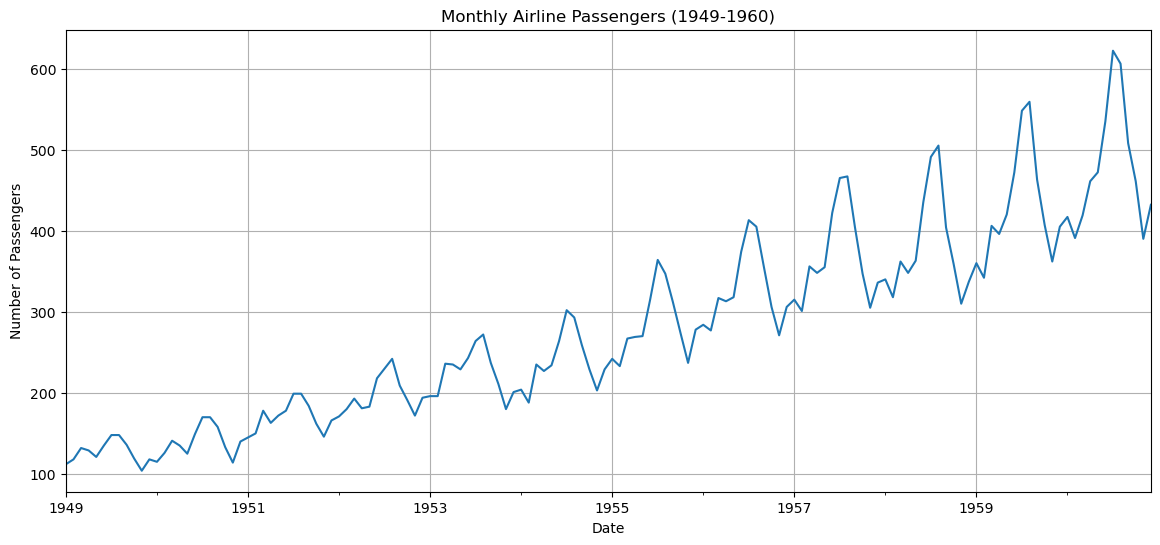

In [36]:
# Convert to datetime and set as index
flights['date'] = pd.to_datetime(flights['year'].astype(str) + '-' + flights['month'].astype(str) + '-01')
flights.set_index('date', inplace=True)

# Plot the full time series
plt.figure(figsize=(14, 6))
flights['passengers'].plot(title='Monthly Airline Passengers (1949-1960)')
plt.ylabel('Number of Passengers')
plt.xlabel('Date')
plt.grid()
plt.show()

After indexing the date and getting a visualization on the Time Series, we can now do the `Seasonality and Trend Decomposition`:

<Figure size 1400x1000 with 0 Axes>

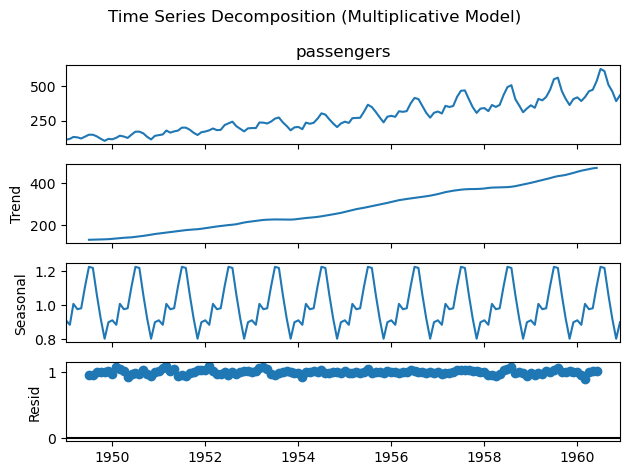

In [37]:
# Decompose the time series
decomposition = seasonal_decompose(flights['passengers'], model='multiplicative')

# Plot decomposition
plt.figure(figsize=(14, 10))
decomposition.plot()
plt.suptitle('Time Series Decomposition (Multiplicative Model)')
plt.tight_layout()
plt.show()

This result tells us a few things about this dataset, in panel order:

1. **Observed data:** It is simply the raw time series data. It has clear upward trend and regular seasonal peaks. As the seasonal swings become larger along the upward trend through time and we observe a "fanning out" of peaks/valleys in the data, we can take that as a basis to use a multiplicative model for seasonal decomposition.
2. **Trend:** By removing the seasonality and the noise, we get the moothed long-term movement of the series (the trend). This trend in particular shows ``steady exponential growth`` in passenger numbers over time. The slight convex in the curve suggests accelerated growth in later years and there seems to be no abrupt changes or structural breaks in the trend.
3. **Seasonal:** This panel shows repeating patterns over fixed intervals (in this case yearly cycles). We see peaks likely in summer seasons (July/August), and troughs in winter months (December/January). Seasonal fluctuations grow over time (higher peaks in later years), which is consistent with a multiplicative model.
4. **Residual:** This is what is left after removing trend and seasonality (noise or unexpected events). In this case, they are mostly random, but with a few small spikes. Those can indicate outliers, but since the scale is so small, this means that the model used in the decomposition explains well most of the variations in the data.

All in all, we got a good seasonal decomposition. Since we used a multiplicative model, we most likely would use multiplicative forecasting models, but we could also do a logarithmic transformation of the data to stabilize the variance.

We can now run autocorrelation analysis:

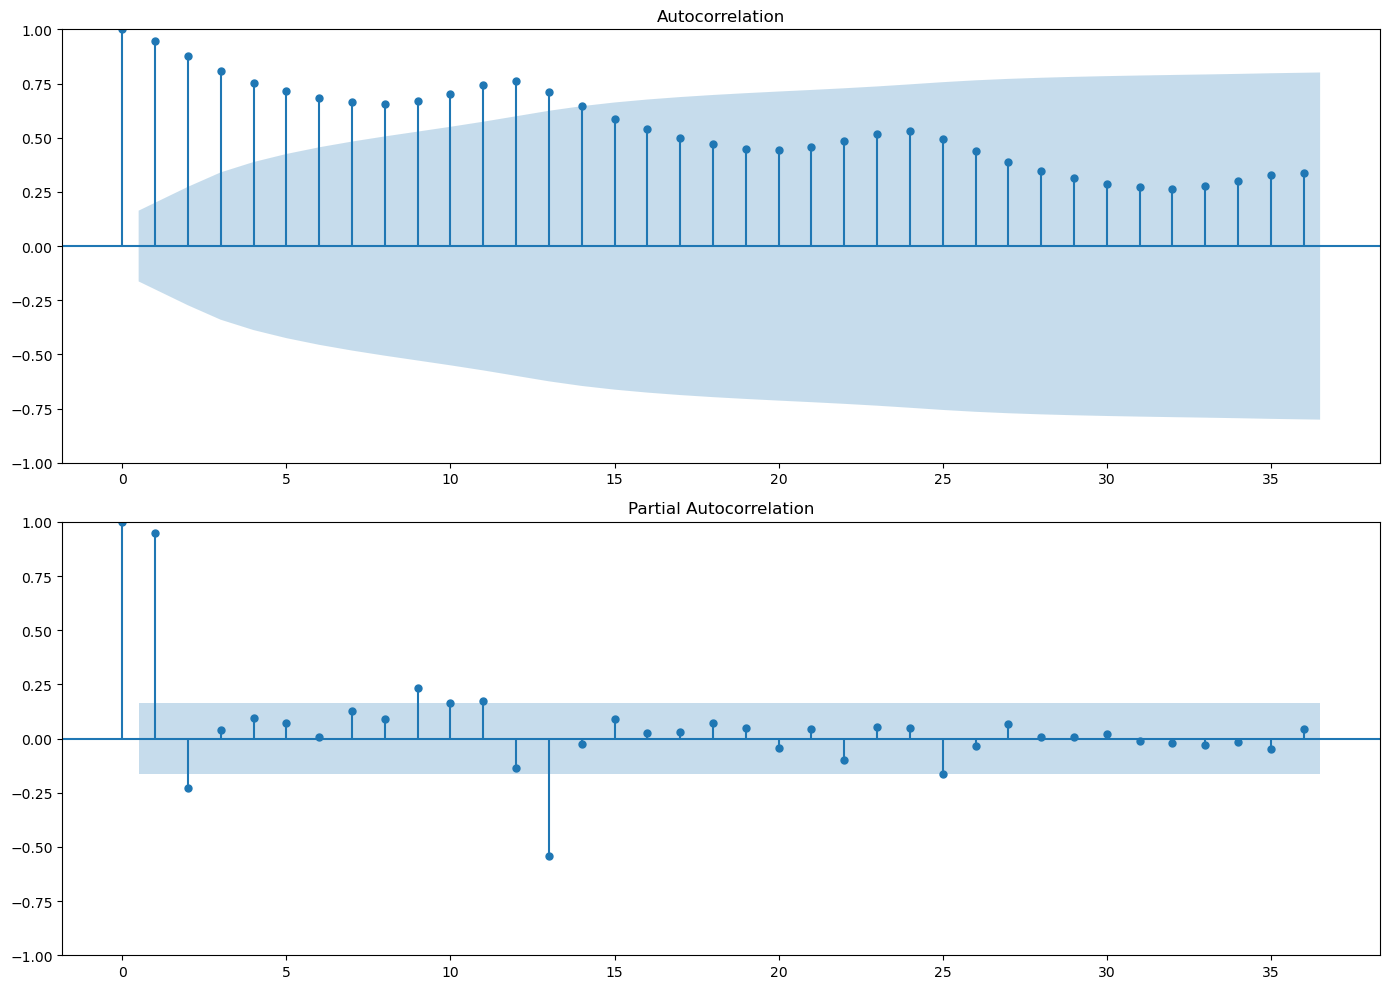

In [38]:
# ACF and PACF plots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))
plot_acf(flights['passengers'], lags=36, ax=ax1)
plot_pacf(flights['passengers'], lags=36, ax=ax2)
plt.tight_layout()
plt.show()

From these plots, we can draw some conclusions:

1. The ACF plot shows a ``gradual decay`` and remains positive over many lags. The pattern suggests that the time series is ``non-stationary``, due to the strong correlation. Finally, the significant lags along all the plot suggest that past values strongly influence the current values;
2. The PACF plot shows a significant spike at `lag 1`, followed by smaller values and a drop-off. This suggests an ``AR(1) process``, meaning that the time series can be modeled with an AutoRegressive (AR) term of order 1. Finally, some significant spikes at higher lags might suggest a mix of AR and MA (Moving Average) components.

These conclusions might help us conclude which forecasting statistical model might be the most appropriate (possibly ARIMA(1,1,0) or ARIMA(1,1,1) or a SARIMA, due to the presence of seasonality). The next steps in model decision would be to run a ``Augmented Dickey-Fuller (ADF)`` test to confirm if differencing is needed, try first-order differencing and re-evaluate ACF/PACF and then decide and fit an ARIMA or SARIMA model, based on the updated insights.

## Feature Engineering

But, for now, we proceed with the Feature Engineering. We can generate time-based features, lag features, rolling statistics and difference features:

In [39]:
# Create time-based features
flights['month_num'] = flights.index.month
flights['quarter'] = flights.index.quarter
flights['year'] = flights.index.year

# Lag features
flights['passengers_lag1'] = flights['passengers'].shift(1)
flights['passengers_lag12'] = flights['passengers'].shift(12)

# Rolling statistics
flights['rolling_mean_12'] = flights['passengers'].rolling(window=12).mean()
flights['rolling_std_12'] = flights['passengers'].rolling(window=12).std()

# Difference features
flights['passengers_diff1'] = flights['passengers'].diff(1)
flights['passengers_diff12'] = flights['passengers'].diff(12)

# Drop rows with NA from lag features
flights.dropna(inplace=True)

## Visual Analysis of Features

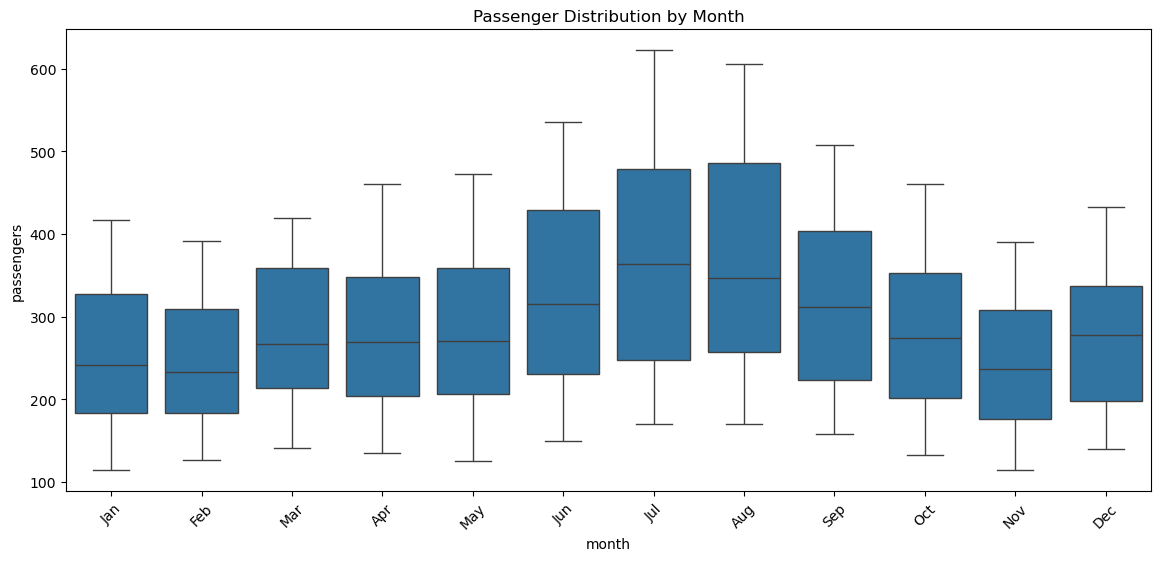

In [40]:
plt.figure(figsize=(14, 6))
sns.boxplot(x='month', y='passengers', data=flights)
plt.title('Passenger Distribution by Month')
plt.xticks(rotation=45)
plt.show()

C:\Users\afons\AppData\Local\Temp\ipykernel_29592\3800968534.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(x='year', y='passengers', data=flights, estimator='sum', ci=None)


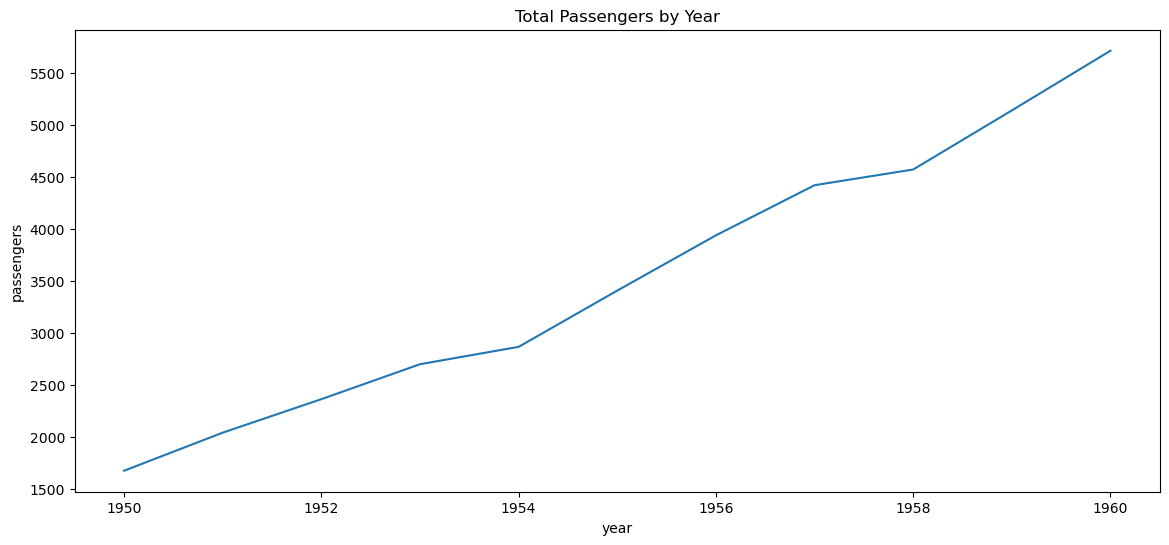

In [41]:
plt.figure(figsize=(14, 6))
sns.lineplot(x='year', y='passengers', data=flights, estimator='sum', ci=None)
plt.title('Total Passengers by Year')
plt.show()

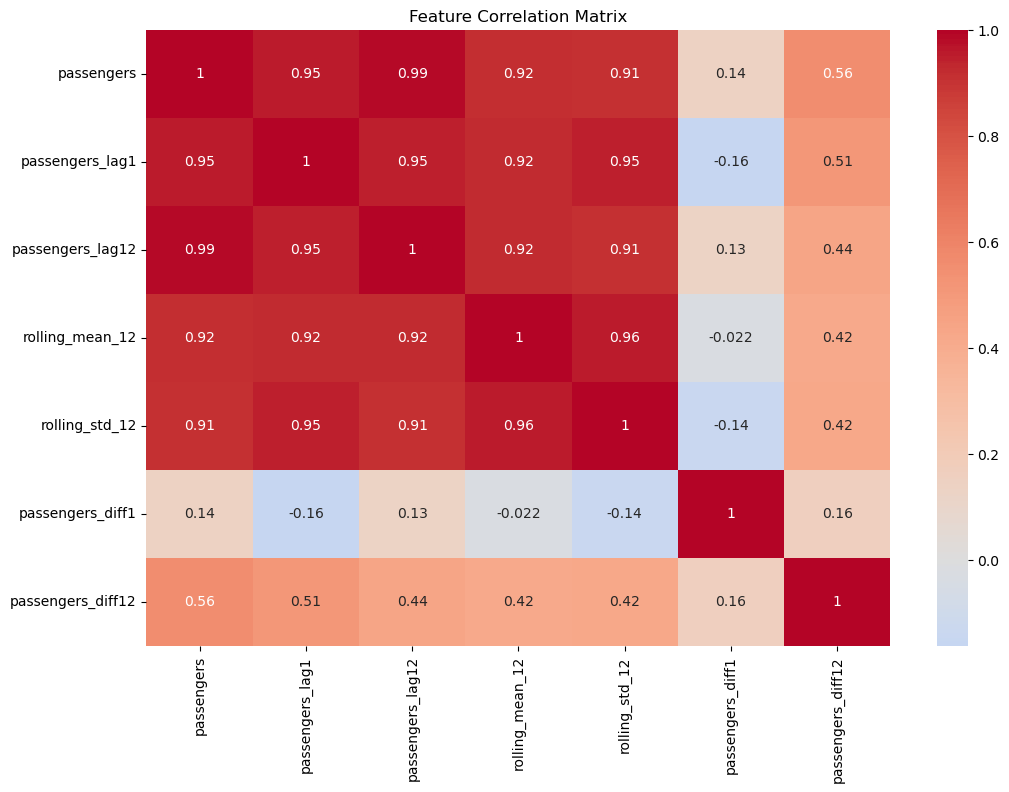

In [42]:
# Calculate correlation matrix
corr_matrix = flights.select_dtypes(include=['float64', 'int64']).corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.show()

## Outlier detection

We try to detect the outliers, using the Z-Score method:


=== Outliers Detected ===
Empty DataFrame
Columns: [passengers, passengers_zscore]
Index: []


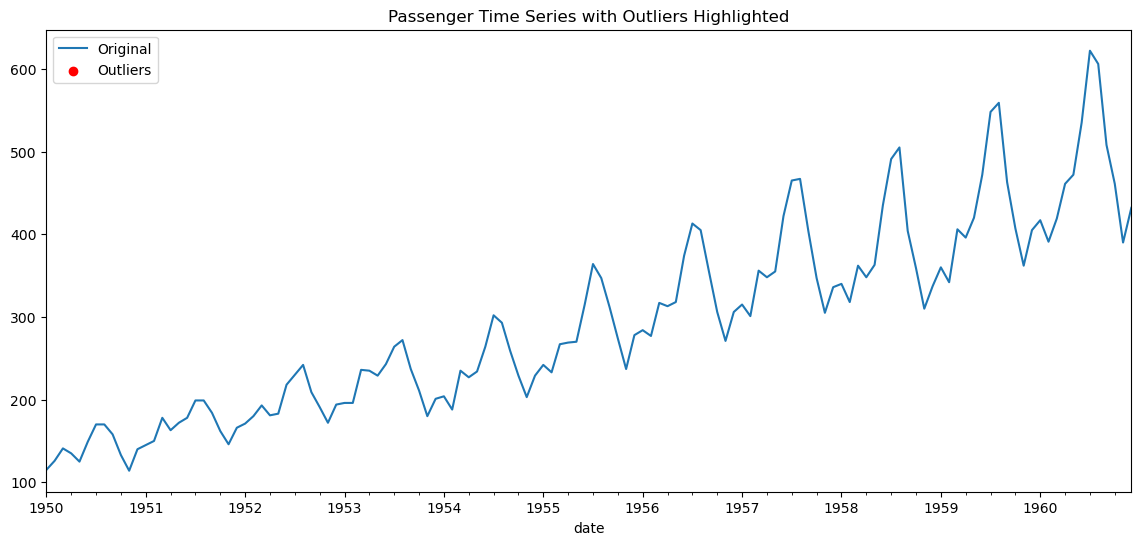

In [43]:
# Z-score method
flights['passengers_zscore'] = stats.zscore(flights['passengers'])
outliers = flights[(flights['passengers_zscore'] > 3) | (flights['passengers_zscore'] < -3)]

print("\n=== Outliers Detected ===")
print(outliers[['passengers', 'passengers_zscore']])

# Visualization
plt.figure(figsize=(14, 6))
flights['passengers'].plot(label='Original')

# Convert datetime index to numeric (matplotlib internal representation)
plt.scatter(outliers.index.astype('datetime64[ns]').astype(np.int64), 
            outliers['passengers'], 
            color='red', 
            label='Outliers')

plt.title('Passenger Time Series with Outliers Highlighted')
plt.legend()
plt.show()

## Stationarity Check

We saw no indication of outliers present in the data, so we can go on to see if the time series is stationary or not. Even though there is indication that it is not, due to the observations on the ACF/PACF plots, we use the ADF test to fully verify:

In [44]:
from statsmodels.tsa.stattools import adfuller

# Augmented Dickey-Fuller test
result = adfuller(flights['passengers'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:')
for key, value in result[4].items():
    print(f'\t{key}: {value}')

ADF Statistic: 0.6881294666354592
p-value: 0.9895979711742351
Critical Values:
	1%: -3.4870216863700767
	5%: -2.8863625166643136
	10%: -2.580009026141913
